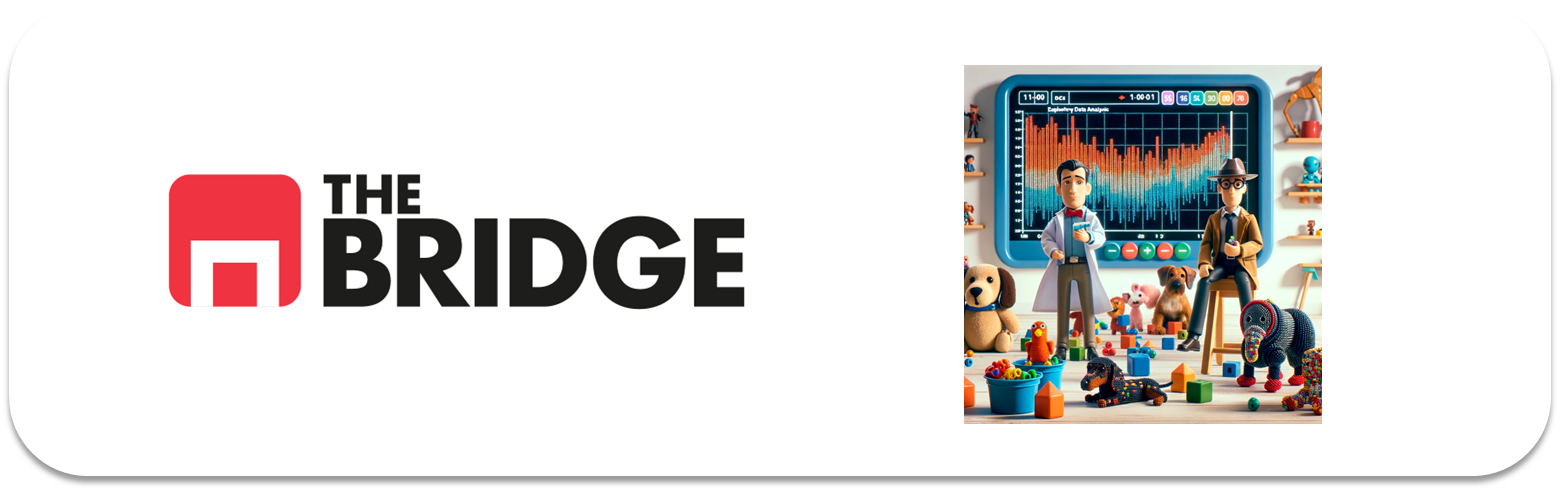

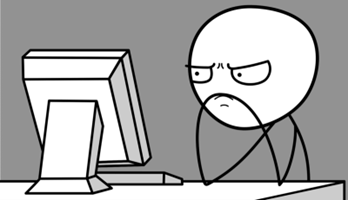

Para ejercitarte y afianzar lo aprendido sobre el estudio estadístico de las relaciones entre variables, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos se subirá a lo largo del sprint.

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, plot_categorical_relationship_fin

### Ejercicio 1

Carga el dataset de admisiones que conoces de la unidad anterior y que se encuentra en la ruta "./data/admission_data.csv", deshazte de las columnas innecesarias

In [4]:
df = pd.read_csv("./data/admission_data.csv")
df

,Unnamed: 0,Year,Major,Gender,Admission
0,0,1973,School of Medicine,F,Rejected
1,1,1973,Department of Economics,M,Accepted
2,2,1973,Other,F,Accepted
3,3,1973,Other,M,Accepted
4,4,1973,Other,M,Rejected
...,...,...,...,...,...
12758,12758,1973,Other,M,Accepted
12759,12759,1973,Department of Mechanical Engineering,M,Accepted
12760,12760,1973,Other,F,Rejected
12761,12761,1973,Other,M,Rejected


### Ejercicio 2

Si recuerdas, las variables "Admission" y "Major" parecían tener una relación clara (la distribución de ratio de admisión variaba claramente entre departamentos o "Majors"). Utiliza el estadístico adecuado (para variables categóricas entre sí, Chi-2) para comprobar que esa hipótesis de relación es estadísticamente significativa, tal y como lo hemos hecho en el workout

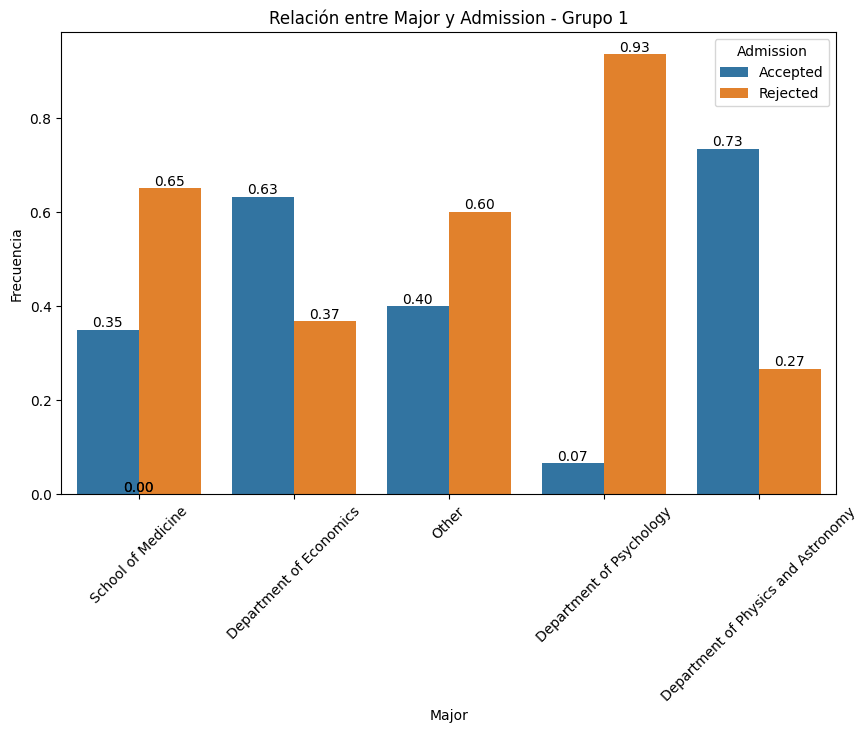

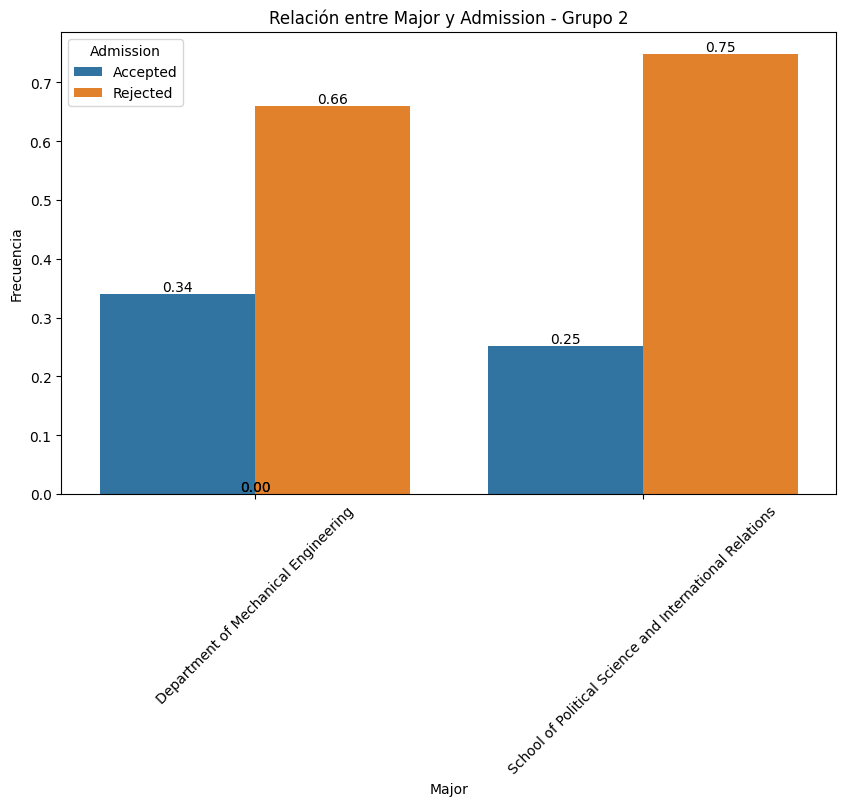

In [6]:
plot_categorical_relationship_fin(df, "Major", "Admission", relative_freq = True, show_values = True)

In [7]:
tabla_contingencia = pd.crosstab(df['Admission'], df['Major'])

tabla_contingencia

Major,Department of Economics,Department of Mechanical Engineering,Department of Physics and Astronomy,Department of Psychology,Other,School of Medicine,School of Political Science and International Relations
Admission,,,,,,,
Accepted,370,269,914,47,3164,321,147
Rejected,215,523,332,667,4760,597,437


In [8]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 1102.860844398216
P-Value: 5.0157639171790306e-235
Grados de Libertad: 6
Tabla de Frecuencias Esperadas:
 [[ 239.81195644  324.66849487  510.77897046  292.69356734 3248.32468855
   376.32030087  239.40202147]
 [ 345.18804356  467.33150513  735.22102954  421.30643266 4675.67531145
   541.67969913  344.59797853]]


In [ ]:
# como pvalue es menor a 0.05 podemos decir que "Major" y "Admision" si están relacionados

### Ejercicio 3

Repite el ejercicio anterior para las variables "Admission" y "Gender".

In [9]:
tabla_contingencia = pd.crosstab(df['Admission'], df['Gender'])

print(tabla_contingencia)


from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Gender        F     M
Admission            
Accepted   1494  3738
Rejected   2827  4704
Valor Chi-Cuadrado: 110.84892145390278
P-Value: 6.385628329926473e-26
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[1771.32899788 3460.67100212]
 [2549.67100212 4981.32899788]]


In [10]:
# como pvalue es menor a 0.05 podemos decir que "Gender" y "Admision" si están relacionados

### Ejercicio 4

Carga el dataset de propinas (tips) que conoces de la unidad anterior y que se encuentra en la ruta "./data/tips.csv", deshazte de las columnas innecesarias

In [11]:
df_tips = pd.read_csv("./data/tips.csv")
df_tips

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


### Ejercicio 5

Comprueba si la hipótesis "No existe una relación entre la propina dejada y el sexo del cliente" tiene confirmación estadística significativa. Para ello emplea el test que creas conveniente a la relación entre las variables "tip" y "sex"(recuerda que aquí disponemos de tres test: t-student, prueba U de Mann-Whitney u el análisis ANOVA).

In [12]:
df_tips["sex"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [ ]:
# Método de la prueba U de Mann-Whitney:

from scipy.stats import mannwhitneyu 

# Hipótesis nula, no existe relación entre las dos variables

#Separamos los datos en dos grupos según la variable categórica
grupo_a = df_tips.loc[df_tips.sex == "Female"]["tip"]
grupo_b = df_tips.loc[df_tips.sex == "Male"]["tip"]

#Aplicamos la prueba y mostramos los resultados
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

#Si el resultado de p es mayor a 0.05 -- No hay evidencia estadística de rechazar la hipótesis nula
#Si el resultado de p es menor a 0.05 -- Hipóteis alternativa - Hay relación entre las dos variables que estamos analizando

Estadístico U: 6369.5
Valor p: 0.38335449359363927


In [14]:
df_tips["size"].unique()

array([2, 3, 4, 1, 6, 5])

### Ejercicio 6

Repite el ejercicio anterior para "tip" y "size" considerando esta última como "categórica". Haz el analisis bivariante visual previo.

In [17]:
from bootcampviztools import plot_grouped_histograms

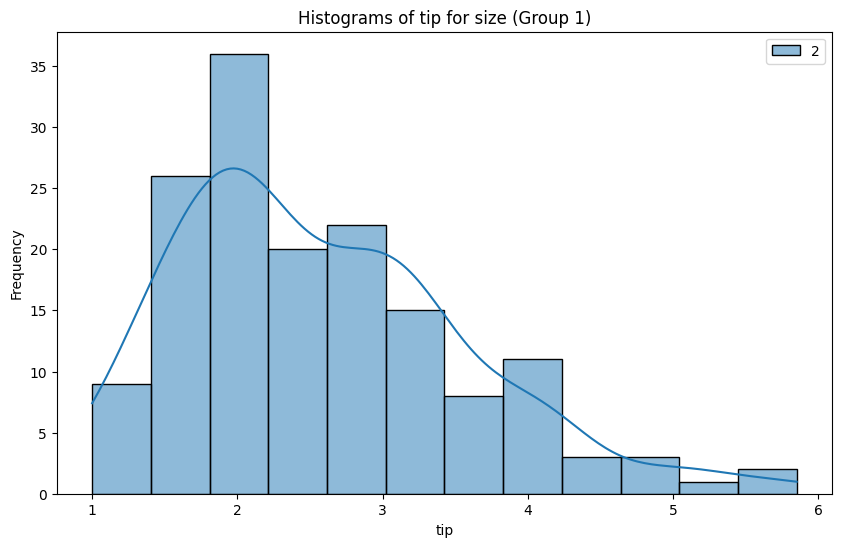

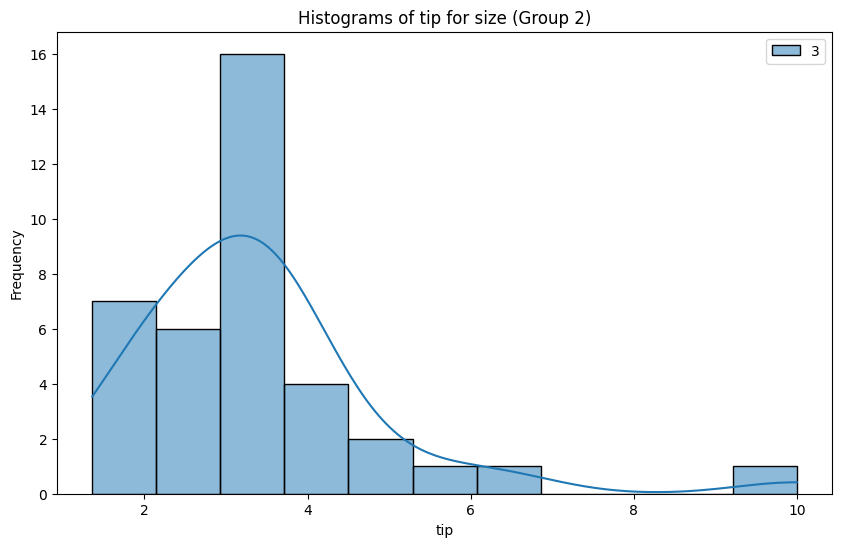

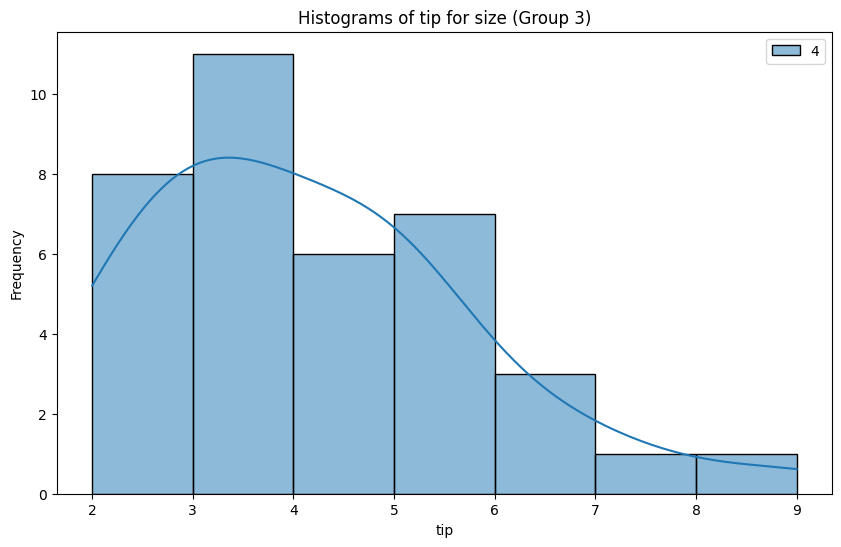

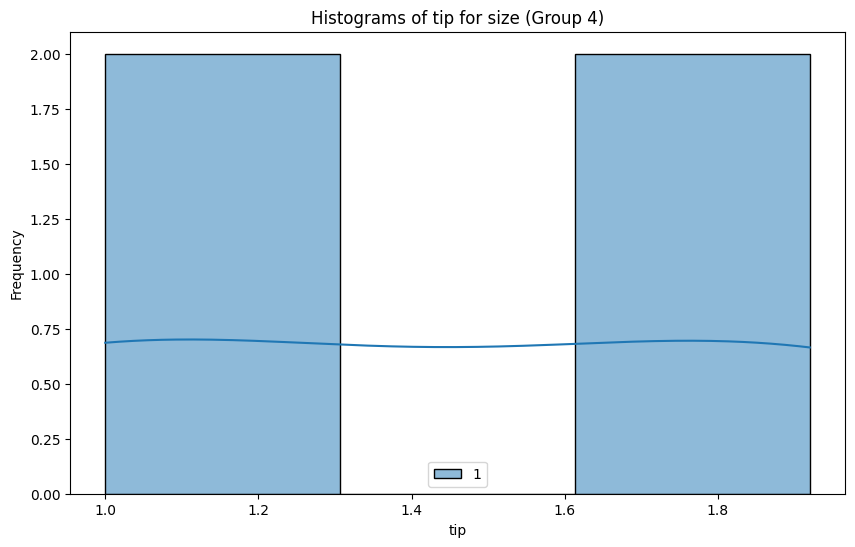

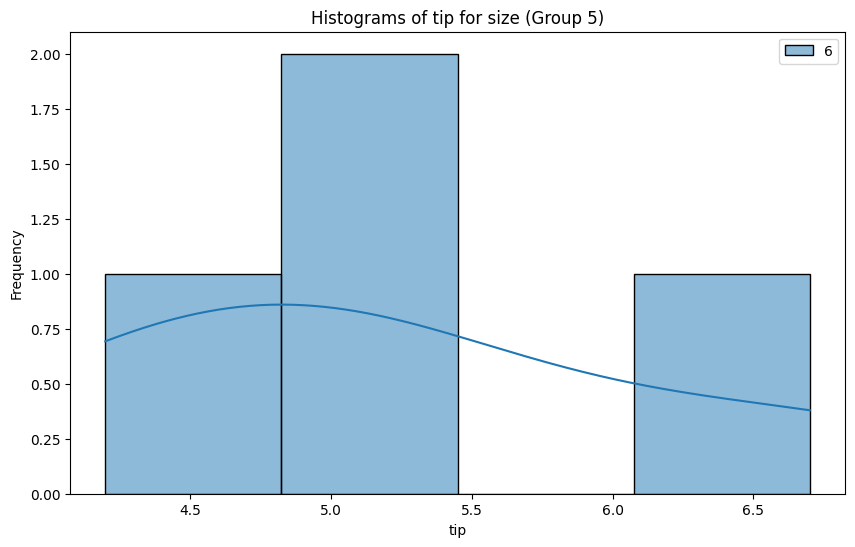

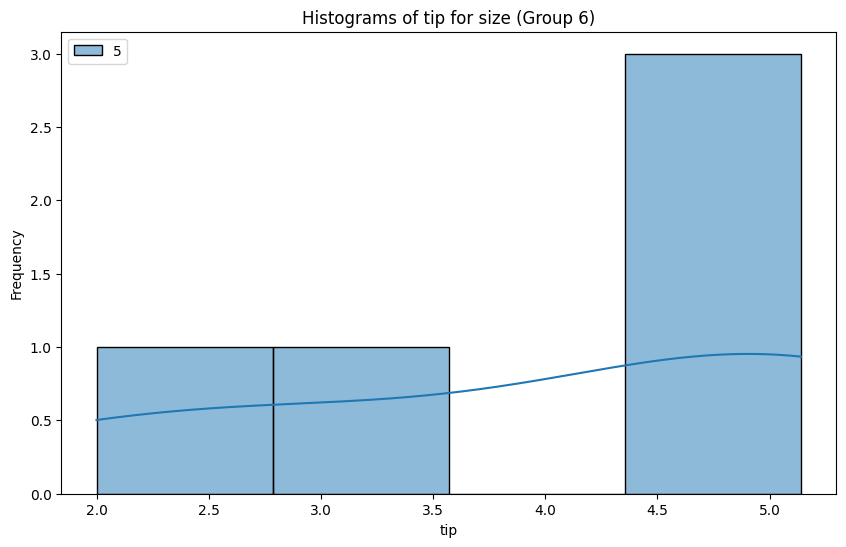

In [21]:
plot_grouped_histograms(df_tips,"size", "tip", 1)

In [23]:
# Método anova (variable categórica no binaria - variable numérica)
from scipy import stats

grupos = df_tips['size'].unique()  # Obtener los valores únicos de la columna categórica
var_cat_grupo = [df_tips[df_tips['size'] == grupo]['tip'] for grupo in grupos] # Obtenemos la variable numérica por valor de la categórica y los incluimos en una lista
var_cat_grupo


f_val, p_val = stats.f_oneway(*var_cat_grupo) # El método * (igual que cuando vimos *args hace mil años) 
                                                    # lo que hace es separar todos los elementos de la lista y pasarselos como argumento a la función
print("Valor F:", f_val)
print("Valor p:", p_val)

#P < 0.05  →  Rechazamos la hipótesis nula (H₀).  
#            Hay evidencia estadística de relación o diferencia entre las variables.
 
#P > 0.05  →  No rechazamos la hipótesis nula (H₀).  
#             No hay evidencia estadística suficiente para afirmar relación o diferencia.


Valor F: 15.746330672727051
Valor p: 2.1694633916208346e-13


### Ejercicio 7

Considera ahora "size" como numérica, muestra el diagrama de dispersión con correlación entre "size" y "tip" y luego aplicales el test para saber si el coeficiente de pearson es estadísticamente significativo. ¿Qué más observas?

In [25]:
from bootcampviztools import grafico_dispersion_con_correlacion

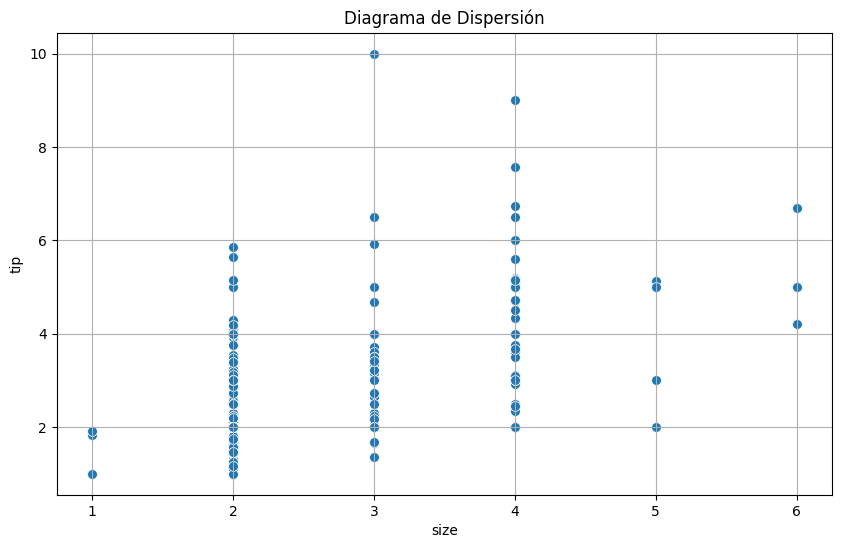

In [29]:
grafico_dispersion_con_correlacion(df_tips,"size","tip", 50)

In [30]:
# El diagrama de dispersión muestra una ligera tendencia ascendente: las propinas tienden a aumentar conforme lo hace el tamaño del grupo, 
# # aunque la variabilidad dentro de cada categoría es alta. El coeficiente de Pearson resulta positivo pero de magnitud baja, 
# #lo que indica una relación lineal débil entre *size* y *tip*. Sin embargo, el p‑value asociado es menor que 0.05, por lo que la correlación es estadísticamente significativa. 
# En conjunto, puede afirmarse que existe una relación positiva entre ambas variables, aunque no es fuerte.
